# Liu Distinctiveness Analysis
Following Ayzenberg et al. (2023) bootstrap framework, applied to
Liu et al. (2025) representational distinctiveness measure.

**Structure:**
1. Load + descriptive stats
2. Controls lateralization
3. Bootstrap control distributions (inline)
4. Individual patient bootstrap (Ayzenberg method)
5. Group-level comparisons
6. Cross-sectional figure
7. Longitudinal T1→T2 (controls + OTC only)
8. Longitudinal figure

**Directionality:** Lower Liu distinctiveness = more selective (better).
"Above CI" = impaired (less distinct than controls).

In [5]:
# CELL 1: Global Setup
# ═══════════════════════════════════════════════════════════════════════════════
# Shared constants, colors, helpers. Identical to summed selectivity notebook.
# ═══════════════════════════════════════════════════════════════════════════════

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
from matplotlib.patches import Patch, Ellipse
from matplotlib.lines import Line2D
from pathlib import Path
from scipy import stats as sp_stats
from scipy.stats import ttest_rel, ttest_ind

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE    = Path(processed_dir)
LIU_DIR = BASE / 'group_results' / 'liu_distinctiveness'
FIG_DIR = BASE / 'group_results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Cope set ──────────────────────────────────────────────────────────────────
COPE_SET = 'differential'

# ── Exclusions ────────────────────────────────────────────────────────────────
EXCLUDE = ['sub-017']

# ── Group colors ──────────────────────────────────────────────────────────────
CTRL_L = '#a0a0a0'
CTRL_R = '#505050'
OTC_L  = '#7398af'
OTC_R  = '#ee7183'
NONOT  = '#FF9800'

# ── Categories (canonical 4 only) ─────────────────────────────────────────────
CATEGORIES = ['face', 'house', 'object', 'word']

CAT_COLORS = {
    'face':   '#cc0066',
    'word':   '#ff8800',
    'house':  '#009900',
    'object': '#0077cc',
}

CAT_MARKERS = {
    'face':   'o',
    'word':   's',
    'house':  '^',
    'object': 'D',
}

# ── Reorganized category per resection side ───────────────────────────────────
REORG = {'left': 'word', 'right': 'face'}

# ── Preferred hemisphere: SAME as selectivity (empirically derived there) ─────
PREFERRED_CTRL_HEMI = {
    'face':   'right',
    'word':   'left',
    'house':  'right',
    'object': 'left',
}
NON_PREFERRED_HEMI = {k: ('left' if v == 'right' else 'right')
                      for k, v in PREFERRED_CTRL_HEMI.items()}

# ── Bootstrap parameters ──────────────────────────────────────────────────────
N_SUBS_BOOT = 4
N_ITER      = 10000

# ── Plot defaults ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})
RNG = np.random.default_rng(42)

# ── Shared helpers ────────────────────────────────────────────────────────────

def short_name(code):
    """Compact subject label for plot annotations."""
    return (code.replace('OTC', '').replace('nonOTC', 'n')
                .replace('control', 'c').replace('sub-', ''))

print(f'Setup complete. COPE_SET={COPE_SET}')
print(f'CATEGORIES: {CATEGORIES}')
print(f'Preferred hemispheres (from selectivity): {PREFERRED_CTRL_HEMI}')
print(f'NOTE: For Liu distinctiveness, LOWER = more selective (better)')

Setup complete. COPE_SET=differential
CATEGORIES: ['face', 'house', 'object', 'word']
Preferred hemispheres (from selectivity): {'face': 'right', 'word': 'left', 'house': 'right', 'object': 'left'}
NOTE: For Liu distinctiveness, LOWER = more selective (better)


In [6]:
# CELL 2: Load Liu Distinctiveness Data
# ═══════════════════════════════════════════════════════════════════════════════
# Load CSV, first session only, split by group.
# Filter to canonical 4 categories only (exclude sub-ROIs like house_PPA).
#
# KEY column differences from selectivity CSV:
#   selectivity: sub, ses, hemi ('left'/'right'), group, intact_hemi
#   liu:         subject_id, session, hemi ('l'/'r'), hemi_label, group, surgery_side
#   For controls: hemi_label = 'left'/'right'
#   For patients: hemi_label = 'intact'/'lesioned'
# ═══════════════════════════════════════════════════════════════════════════════

METRIC = 'liu_distinctiveness'

liu_file = LIU_DIR / f'liu_distinctiveness_{COPE_SET}.csv'
if not liu_file.exists():
    raise FileNotFoundError(f'{liu_file}')

df_liu = pd.read_csv(liu_file)

# Filter to canonical 4 categories only
df_liu = df_liu[df_liu['category'].isin(CATEGORIES)]

# Exclude sub-017
df_liu = df_liu[~df_liu['subject_id'].isin(EXCLUDE)]

# First session only
first = (df_liu.groupby('subject_id')['session'].min()
              .reset_index().rename(columns={'session': 'fs'}))
df_liu = df_liu.merge(first, on='subject_id')
df_liu = df_liu[df_liu['session'] == df_liu['fs']]

# Split by group
ctrl = df_liu[df_liu['status'] == 'control'].copy()
otc  = df_liu[(df_liu['group'] == 'OTC') & (df_liu['hemi_label'] == 'intact')].copy()
nonotc = df_liu[(df_liu['group'] == 'nonOTC') & (df_liu['hemi_label'] == 'intact')].copy()

# Derive surgery_side for consistency
otc['surgery_side'] = otc['surgery_side'].fillna(
    otc['hemi'].map(lambda h: 'right' if h == 'l' else 'left'))
nonotc['surgery_side'] = nonotc['surgery_side'].fillna(
    nonotc['hemi'].map(lambda h: 'right' if h == 'l' else 'left'))

# Derive intact_hemi for patients
otc['intact_hemi'] = otc['surgery_side'].map(lambda s: 'right' if s == 'left' else 'left')
nonotc['intact_hemi'] = nonotc['surgery_side'].map(lambda s: 'right' if s == 'left' else 'left')

# Pivot controls for lateralization tests (need left vs right per subject)
ctrl_wide = {}
for cat in CATEGORIES:
    cat_df = ctrl[ctrl['category'] == cat][['subject_id', 'hemi_label', METRIC]]
    pivoted = cat_df.pivot(index='subject_id', columns='hemi_label', values=METRIC).dropna()
    ctrl_wide[cat] = pivoted

print(f'Controls: {ctrl["subject_id"].nunique()}, '
      f'OTC: {otc["subject_id"].nunique()}, '
      f'nonOTC: {nonotc["subject_id"].nunique()}')

# ── Descriptive stats ─────────────────────────────────────────────────────────
print(f'\n{"Category":<10} {"Group":<10} {"Hemi":<8} {"M":>8} {"SD":>8} {"n":>5}')
print('─' * 50)
for cat in CATEGORIES:
    ref = PREFERRED_CTRL_HEMI[cat]
    cv = ctrl[(ctrl['category'] == cat) &
              (ctrl['hemi_label'] == ref)][METRIC].values
    print(f'{cat:<10} {"ctrl pref":<10} {ref:<8} {np.mean(cv):>8.3f} {np.std(cv):>8.3f} {len(cv):>5}')
    pv = otc[otc['category'] == cat][METRIC].values
    if len(pv) > 0:
        print(f'{"":<10} {"OTC int":<10} {"intact":<8} {np.mean(pv):>8.3f} {np.std(pv):>8.3f} {len(pv):>5}')
    nv = nonotc[nonotc['category'] == cat][METRIC].values
    if len(nv) > 0:
        print(f'{"":<10} {"nonOTC":<10} {"intact":<8} {np.mean(nv):>8.3f} {np.std(nv):>8.3f} {len(nv):>5}')

Controls: 22, OTC: 15, nonOTC: 9

Category   Group      Hemi            M       SD     n
──────────────────────────────────────────────────
face       ctrl pref  right       0.710    0.380    21
           OTC int    intact      0.801    0.278    14
           nonOTC     intact      0.659    0.223     9
house      ctrl pref  right       0.107    0.787    22
           OTC int    intact      0.552    0.632    15
           nonOTC     intact      0.334    0.558     9
object     ctrl pref  left        1.028    0.324    22
           OTC int    intact      1.189    0.416    15
           nonOTC     intact      1.224    0.302     9
word       ctrl pref  left        0.508    0.351    21
           OTC int    intact      0.807    0.492    12
           nonOTC     intact      0.791    0.443     9


In [7]:
# CELL 3: Controls Lateralization
# ═══════════════════════════════════════════════════════════════════════════════
# Paired t-test, LH vs RH, Bonferroni-corrected.
# Uses PREFERRED_CTRL_HEMI from selectivity — this cell VERIFIES consistency.
#
# NOTE: For Liu distinctiveness, lower = more selective.
# So if preferred hemi has LOWER values, that's the more selective side.
# ═══════════════════════════════════════════════════════════════════════════════

n_comparisons = len(CATEGORIES)
bonferroni_alpha = 0.05 / n_comparisons

print('='*70)
print('CONTROLS LATERALIZATION (LH vs RH, paired t, Bonferroni-corrected)')
print('NOTE: Lower Liu = more selective/distinct')
print('='*70)

lat_results = {}
for cat in CATEGORIES:
    piv = ctrl_wide[cat]
    if len(piv) < 3:
        continue
    lh, rh = piv['left'].values, piv['right'].values
    n = len(lh)
    diff = lh - rh
    t_stat, t_p = ttest_rel(lh, rh)
    d = diff.mean() / diff.std() if diff.std() > 0 else np.nan
    bonf_sig = t_p < bonferroni_alpha

    # For Liu: lower = more selective, so "LH < RH" means LH is more selective
    if diff.mean() < 0:
        direction = 'LH < RH (LH more selective)'
    else:
        direction = 'LH > RH (RH more selective)'

    lat_results[cat] = {'t': t_stat, 'p': t_p, 'd': d, 'sig': bonf_sig, 'dir': direction}

    # Check consistency with selectivity preferred hemi
    sel_pref = PREFERRED_CTRL_HEMI[cat]
    # For Liu, the MORE selective hemi (lower values) should be the preferred one
    liu_pref = 'left' if lh.mean() < rh.mean() else 'right'
    match = '✓' if liu_pref == sel_pref else '✗ MISMATCH'

    print(f'\n  {cat}:  n={n}')
    print(f'    LH: M={lh.mean():.3f} (SD={lh.std():.3f})')
    print(f'    RH: M={rh.mean():.3f} (SD={rh.std():.3f})')
    print(f'    t({n-1}) = {t_stat:.3f}, p = {t_p:.4f}, d = {d:.3f}')
    print(f'    Bonferroni (α={bonferroni_alpha:.4f}): '
          f'{"SIGNIFICANT" if bonf_sig else "ns"} — {direction}')
    print(f'    Selectivity preferred={sel_pref}, Liu more-selective={liu_pref}  {match}')

CONTROLS LATERALIZATION (LH vs RH, paired t, Bonferroni-corrected)
NOTE: Lower Liu = more selective/distinct

  face:  n=21
    LH: M=0.706 (SD=0.359)
    RH: M=0.710 (SD=0.380)
    t(20) = -0.036, p = 0.9715, d = -0.008
    Bonferroni (α=0.0125): ns — LH < RH (LH more selective)
    Selectivity preferred=right, Liu more-selective=left  ✗ MISMATCH

  house:  n=22
    LH: M=0.479 (SD=0.787)
    RH: M=0.107 (SD=0.787)
    t(21) = 1.642, p = 0.1155, d = 0.358
    Bonferroni (α=0.0125): ns — LH > RH (RH more selective)
    Selectivity preferred=right, Liu more-selective=right  ✓

  object:  n=22
    LH: M=1.028 (SD=0.324)
    RH: M=1.170 (SD=0.517)
    t(21) = -1.284, p = 0.2130, d = -0.280
    Bonferroni (α=0.0125): ns — LH < RH (LH more selective)
    Selectivity preferred=left, Liu more-selective=left  ✓

  word:  n=15
    LH: M=0.589 (SD=0.356)
    RH: M=0.390 (SD=0.482)
    t(14) = 1.402, p = 0.1826, d = 0.375
    Bonferroni (α=0.0125): ns — LH > RH (RH more selective)
    Selectivity

In [8]:
# CELL 4: Bootstrap Control Liu Distinctiveness Distributions (inline)
# ═══════════════════════════════════════════════════════════════════════════════
# No pre-computed resamples exist for Liu distinctiveness.
# Generate them here: for each category × hemisphere, draw n=4 controls
# with replacement, compute mean Liu, repeat 10,000 times.
#
# Matches selectivity bootstrap approach (03_resample_selectivity.py).
# ═══════════════════════════════════════════════════════════════════════════════

rng_boot = np.random.default_rng(42)
boot_liu = {}  # key = 'category_hemi', value = array of 10000 bootstrapped means

print('='*70)
print(f'Bootstrapping control Liu distinctiveness distributions')
print(f'  n_subs={N_SUBS_BOOT}, iterations={N_ITER}')
print('='*70)

for cat in CATEGORIES:
    for hemi_label in ['left', 'right']:
        key = f'{cat}_{hemi_label}'
        vals = ctrl[(ctrl['category'] == cat) &
                    (ctrl['hemi_label'] == hemi_label)][METRIC].dropna().values

        if len(vals) < N_SUBS_BOOT:
            print(f'  WARNING: {key} has only {len(vals)} controls, skipping')
            continue

        idx = rng_boot.choice(len(vals), size=(N_ITER, N_SUBS_BOOT), replace=True)
        boot_liu[key] = vals[idx].mean(axis=1)

        ci_lo = np.percentile(boot_liu[key], 2.5)
        ci_hi = np.percentile(boot_liu[key], 97.5)
        print(f'  {key}: n={len(vals)}, boot M={boot_liu[key].mean():.3f}, '
              f'CI=[{ci_lo:.3f}, {ci_hi:.3f}]')

print(f'\nGenerated {len(boot_liu)} bootstrap distributions.')

Bootstrapping control Liu distinctiveness distributions
  n_subs=4, iterations=10000
  face_left: n=21, boot M=0.705, CI=[0.344, 1.054]
  face_right: n=21, boot M=0.709, CI=[0.362, 1.102]
  house_left: n=22, boot M=0.477, CI=[-0.293, 1.254]
  house_right: n=22, boot M=0.103, CI=[-0.560, 0.939]
  object_left: n=22, boot M=1.030, CI=[0.727, 1.348]
  object_right: n=22, boot M=1.170, CI=[0.633, 1.624]
  word_left: n=21, boot M=0.507, CI=[0.157, 0.837]
  word_right: n=15, boot M=0.389, CI=[-0.086, 0.853]

Generated 8 bootstrap distributions.


In [9]:
# CELL 5: Individual Patient Bootstrap (Ayzenberg Method)
# ═══════════════════════════════════════════════════════════════════════════════
#
# PRIMARY:   patient intact hemi vs. controls' PREFERRED hemi
# SECONDARY: patient intact hemi vs. controls' NON-PREFERRED hemi
#
# DIRECTIONALITY (flipped from selectivity):
#   Liu: lower = more selective (better)
#   - ABOVE preferred CI (97.5th) = impaired (less distinct than controls)
#   - For reorg tests:
#     within preferred CI         → reorganization
#     also BELOW non-preferred CI → STRONG reorganization (more distinct
#                                   than even the weaker hemisphere)
#     above preferred CI          → impaired
# ═══════════════════════════════════════════════════════════════════════════════

print('='*70)
print('INDIVIDUAL PATIENT BOOTSTRAP (Ayzenberg method, Liu distinctiveness)')
print('  NOTE: Lower = more selective. Above CI = IMPAIRED.')
print('  Primary:   intact vs. controls preferred hemi')
print('  Secondary: intact vs. controls non-preferred hemi')
print('  Reorg interpretation:')
print('    within preferred CI           → reorganization')
print('    also below non-preferred CI   → STRONG reorganization')
print('    above preferred CI            → impaired')
print('='*70)

corrected_rows = []

for grp_label in ['OTC', 'nonOTC']:
    grp_df = otc if grp_label == 'OTC' else nonotc
    if grp_df.empty:
        continue

    print(f'\n{"="*70}\n  {grp_label}\n{"="*70}')

    for sub in sorted(grp_df['subject_id'].unique()):
        sub_data = grp_df[grp_df['subject_id'] == sub]
        intact = sub_data['intact_hemi'].iloc[0]
        sub_code = sub_data['subject'].iloc[0]

        print(f'\n  {sub_code} (intact {intact}):')

        for cat in CATEGORIES:
            pt_row = sub_data[sub_data['category'] == cat]
            if pt_row.empty:
                print(f'    {cat}: no data')
                continue
            pt_val = pt_row[METRIC].values[0]

            pref = PREFERRED_CTRL_HEMI[cat]
            nonpref = NON_PREFERRED_HEMI[cat]
            is_reorg = (intact != pref)
            test_type = 'reorg' if is_reorg else 'normal'

            # ── Primary: vs preferred ─────────────────────────────────────
            pref_key = f'{cat}_{pref}'
            pref_dist = boot_liu[pref_key]
            pref_pctile = float(np.mean(pref_dist <= pt_val) * 100)
            pref_ci_lo = np.percentile(pref_dist, 2.5)
            pref_ci_hi = np.percentile(pref_dist, 97.5)
            # Liu: ABOVE upper CI = impaired (less distinct)
            above_pref = pt_val > pref_ci_hi

            # ── Secondary: vs non-preferred ───────────────────────────────
            nonpref_key = f'{cat}_{nonpref}'
            nonpref_dist = boot_liu[nonpref_key]
            nonpref_pctile = float(np.mean(nonpref_dist <= pt_val) * 100)
            nonpref_ci_lo = np.percentile(nonpref_dist, 2.5)
            nonpref_ci_hi = np.percentile(nonpref_dist, 97.5)
            # Liu: BELOW lower CI = MORE distinct than non-preferred
            below_nonpref = pt_val < nonpref_ci_lo

            # ── Interpretation ────────────────────────────────────────────
            if is_reorg:
                if not above_pref and below_nonpref:
                    interp = 'STRONG reorg'
                elif not above_pref:
                    interp = 'reorg (within preferred)'
                else:
                    interp = 'impaired'
            else:
                if not above_pref:
                    interp = 'normal'
                else:
                    interp = 'impaired'

            pref_marker = '*' if above_pref else '-'
            nonpref_marker = '+' if below_nonpref else '-'

            print(f'    {cat} [{test_type}]: val={pt_val:.3f}  '
                  f'vs pref({pref})={pref_pctile:.0f}%{pref_marker}  '
                  f'vs nonpref({nonpref})={nonpref_pctile:.0f}%{nonpref_marker}  '
                  f'→ {interp}')

            corrected_rows.append({
                'sub': sub, 'subject': sub_code,
                'group': grp_label, 'intact_hemi': intact,
                'category': cat, 'value': pt_val, 'test_type': test_type,
                'pref_hemi': pref, 'pref_pctile': pref_pctile,
                'pref_ci_lo': pref_ci_lo, 'pref_ci_hi': pref_ci_hi,
                'above_pref': above_pref,
                'nonpref_hemi': nonpref, 'nonpref_pctile': nonpref_pctile,
                'nonpref_ci_lo': nonpref_ci_lo, 'nonpref_ci_hi': nonpref_ci_hi,
                'below_nonpref': below_nonpref,
                'interpretation': interp,
            })

df_corrected = pd.DataFrame(corrected_rows)

# ── Summary: Reorganization tests ─────────────────────────────────────────
print('\n' + '='*70)
print('SUMMARY: Reorganization tests (intact = non-preferred hemi)')
print('  "within_pref" = NOT above preferred CI = evidence of reorganization')
print('  "below_nonpref" = more distinct than non-preferred = STRONG reorg')
print('='*70)
for grp_label in ['OTC', 'nonOTC']:
    grp = df_corrected[(df_corrected['group'] == grp_label) &
                        (df_corrected['test_type'] == 'reorg')]
    if grp.empty:
        continue
    print(f'\n  {grp_label}:')
    print(f'  {"category":<10} {"n":>3} {"within_pref":>12} {"below_nonpref":>14} {"STRONG":>7}')
    for cat in CATEGORIES:
        c = grp[grp['category'] == cat]
        n = len(c)
        if n == 0:
            continue
        n_within = int((~c['above_pref']).sum())
        n_below = int(c['below_nonpref'].sum())
        n_strong = int(((~c['above_pref']) & c['below_nonpref']).sum())
        print(f'  {cat:<10} {n:>3} {n_within:>8}/{n:<3} {n_below:>10}/{n:<3} {n_strong:>4}/{n}')

# ── Summary: Normal tests ─────────────────────────────────────────────────
print('\n' + '='*70)
print('SUMMARY: Normal tests (intact = preferred hemi)')
print('  "within_pref" = NOT above preferred CI = normal')
print('='*70)
for grp_label in ['OTC', 'nonOTC']:
    grp = df_corrected[(df_corrected['group'] == grp_label) &
                        (df_corrected['test_type'] == 'normal')]
    if grp.empty:
        continue
    print(f'\n  {grp_label}:')
    print(f'  {"category":<10} {"n":>3} {"within_pref":>12} {"impaired":>9}')
    for cat in CATEGORIES:
        c = grp[grp['category'] == cat]
        n = len(c)
        if n == 0:
            continue
        n_within = int((~c['above_pref']).sum())
        n_impaired = int(c['above_pref'].sum())
        print(f'  {cat:<10} {n:>3} {n_within:>8}/{n:<3} {n_impaired:>5}/{n}')

INDIVIDUAL PATIENT BOOTSTRAP (Ayzenberg method, Liu distinctiveness)
  NOTE: Lower = more selective. Above CI = IMPAIRED.
  Primary:   intact vs. controls preferred hemi
  Secondary: intact vs. controls non-preferred hemi
  Reorg interpretation:
    within preferred CI           → reorganization
    also below non-preferred CI   → STRONG reorganization
    above preferred CI            → impaired

  OTC

  OTC004 (intact left):
    face [reorg]: val=0.424  vs pref(right)=6%-  vs nonpref(left)=6%-  → reorg (within preferred)
    house [reorg]: val=0.781  vs pref(right)=94%-  vs nonpref(left)=77%-  → reorg (within preferred)
    object [normal]: val=0.734  vs pref(left)=3%-  vs nonpref(right)=5%-  → normal
    word [normal]: val=0.439  vs pref(left)=35%-  vs nonpref(right)=57%-  → normal

  OTC008 (intact left):
    face [reorg]: val=1.108  vs pref(right)=98%*  vs nonpref(left)=99%-  → impaired
    house [reorg]: val=1.128  vs pref(right)=99%*  vs nonpref(left)=95%-  → impaired
    objec

In [10]:
# CELL 6: Group-Level Comparisons
# ═══════════════════════════════════════════════════════════════════════════════
#
# 6a: Patient group mean vs. bootstrapped preferred-hemi controls
# 6b: Within-group hemisphere differences
# ═══════════════════════════════════════════════════════════════════════════════

# ── 6a: Group mean vs bootstrap ──────────────────────────────────────────────
print('='*70)
print('6a. GROUP-LEVEL BOOTSTRAP: patient group mean vs controls preferred hemi')
print('    NOTE: For Liu, ABOVE CI = impaired (less distinct)')
print('='*70)

for grp_label, grp_df in [('OTC', otc), ('nonOTC', nonotc)]:
    print(f'\n--- {grp_label} vs Controls (preferred hemi) ---')
    for cat in CATEGORIES:
        pt_vals = grp_df[grp_df['category'] == cat][METRIC].dropna().values
        if len(pt_vals) == 0:
            continue
        pt_mean = pt_vals.mean()

        pref = PREFERRED_CTRL_HEMI[cat]
        ctrl_vals = ctrl[(ctrl['category'] == cat) &
                         (ctrl['hemi_label'] == pref)][METRIC].values
        ctrl_mean = ctrl_vals.mean()
        ctrl_sd = ctrl_vals.std(ddof=1)

        boot_key = f'{cat}_{pref}'
        boot_dist = boot_liu[boot_key]
        pt_pctile = float(np.mean(boot_dist <= pt_mean) * 100)
        ci_lo = np.percentile(boot_dist, 2.5)
        ci_hi = np.percentile(boot_dist, 97.5)
        above = pt_mean > ci_hi  # Liu: above = impaired

        d = (pt_mean - ctrl_mean) / ctrl_sd if ctrl_sd > 0 else np.nan
        sig_str = '**ABOVE CI (impaired)**' if above else 'within CI'

        print(f'  {cat}: pt M={pt_mean:.3f} (n={len(pt_vals)}), '
              f'ctrl {pref} M={ctrl_mean:.3f} (n={len(ctrl_vals)})')
        print(f'    pctile={pt_pctile:.1f}%, CI=[{ci_lo:.3f}, {ci_hi:.3f}] — {sig_str}, d={d:.3f}')

# ── 6b: Within-group hemisphere differences ──────────────────────────────────
print('\n' + '='*70)
print('6b. WITHIN-GROUP HEMISPHERE DIFFERENCES')
print('='*70)

# Controls: paired t-test (same subjects, both hemispheres)
print('\n--- Controls (paired t-test, LH vs RH) ---')
for cat in CATEGORIES:
    piv = ctrl_wide[cat]
    if len(piv) < 3:
        continue
    t, p = ttest_rel(piv['left'].values, piv['right'].values)
    diff = piv['left'].values - piv['right'].values
    d = diff.mean() / diff.std() if diff.std() > 0 else np.nan
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f'  {cat}: LH M={piv["left"].mean():.3f}, RH M={piv["right"].mean():.3f}, '
          f't({len(piv)-1})={t:.3f}, p={p:.4f} {sig}, d={d:.3f}')

# OTC: independent t-test (L resection vs R resection = different patients)
for grp_label, grp_df in [('OTC', otc), ('nonOTC', nonotc)]:
    print(f'\n--- {grp_label} (independent t-test, L vs R resection) ---')
    for cat in CATEGORIES:
        l_vals = grp_df[(grp_df['category'] == cat) &
                        (grp_df['surgery_side'] == 'left')][METRIC].dropna().values
        r_vals = grp_df[(grp_df['category'] == cat) &
                        (grp_df['surgery_side'] == 'right')][METRIC].dropna().values
        if len(l_vals) < 2 or len(r_vals) < 2:
            print(f'  {cat}: L resec n={len(l_vals)}, R resec n={len(r_vals)} — too few')
            continue
        t, p = ttest_ind(l_vals, r_vals)
        pooled_sd = np.sqrt(((len(l_vals)-1)*l_vals.std(ddof=1)**2 +
                             (len(r_vals)-1)*r_vals.std(ddof=1)**2) /
                            (len(l_vals)+len(r_vals)-2))
        d = (l_vals.mean() - r_vals.mean()) / pooled_sd if pooled_sd > 0 else np.nan
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        print(f'  {cat}: L resec(intact RH) M={l_vals.mean():.3f}(n={len(l_vals)}), '
              f'R resec(intact LH) M={r_vals.mean():.3f}(n={len(r_vals)}), '
              f't={t:.3f}, p={p:.4f} {sig}, d={d:.3f}')

6a. GROUP-LEVEL BOOTSTRAP: patient group mean vs controls preferred hemi
    NOTE: For Liu, ABOVE CI = impaired (less distinct)

--- OTC vs Controls (preferred hemi) ---
  face: pt M=0.801 (n=14), ctrl right M=0.710 (n=21)
    pctile=69.2%, CI=[0.362, 1.102] — within CI, d=0.235
  house: pt M=0.552 (n=15), ctrl right M=0.107 (n=22)
    pctile=86.2%, CI=[-0.560, 0.939] — within CI, d=0.553
  object: pt M=1.189 (n=15), ctrl left M=1.028 (n=22)
    pctile=83.2%, CI=[0.727, 1.348] — within CI, d=0.486
  word: pt M=0.807 (n=12), ctrl left M=0.508 (n=21)
    pctile=96.1%, CI=[0.157, 0.837] — within CI, d=0.832

--- nonOTC vs Controls (preferred hemi) ---
  face: pt M=0.659 (n=9), ctrl right M=0.710 (n=21)
    pctile=41.8%, CI=[0.362, 1.102] — within CI, d=-0.130
  house: pt M=0.334 (n=9), ctrl right M=0.107 (n=22)
    pctile=73.4%, CI=[-0.560, 0.939] — within CI, d=0.282
  object: pt M=1.224 (n=9), ctrl left M=1.028 (n=22)
    pctile=88.4%, CI=[0.727, 1.348] — within CI, d=0.593
  word: pt M

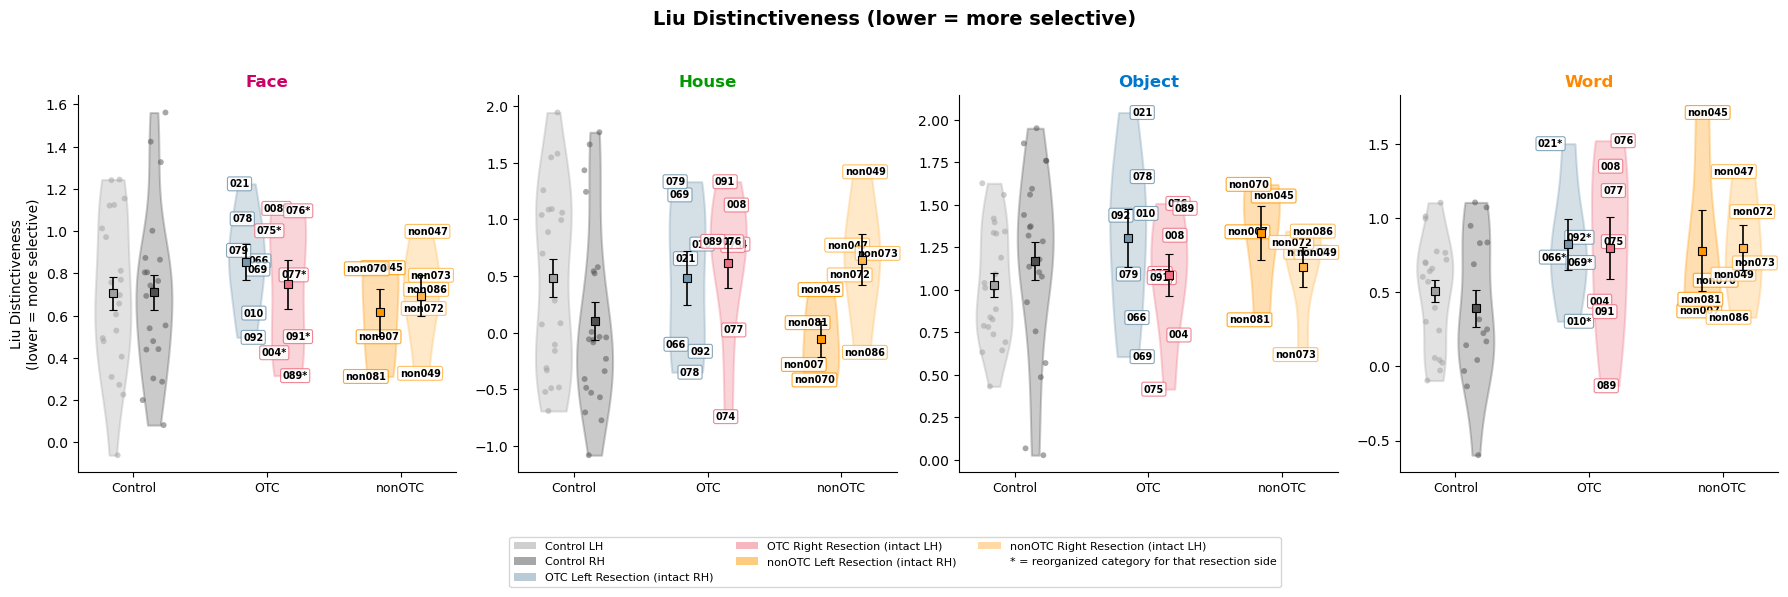

Saved: fig_liu_distinctiveness_differential.png


In [11]:
# CELL 7: Figure — Liu Distinctiveness (cross-sectional)
# ═══════════════════════════════════════════════════════════════════════════════
# Violin + jitter: controls L/R, OTC by resection side, nonOTC by resection side
# Same layout as summed selectivity figure for consistency.
# ═══════════════════════════════════════════════════════════════════════════════

n_cats = len(CATEGORIES)
fig, axes = plt.subplots(1, n_cats, figsize=(4.5 * n_cats, 5.5), sharey=False)

for col_idx, cat in enumerate(CATEGORIES):
    ax = axes[col_idx]
    vd, vp, vc = [], [], []

    # ── Controls L/R ──────────────────────────────────────────────────────
    cl = ctrl[(ctrl['category'] == cat) & (ctrl['hemi_label'] == 'left')][METRIC].values
    cr = ctrl[(ctrl['category'] == cat) & (ctrl['hemi_label'] == 'right')][METRIC].values

    for vals, pos, color in [(cl, 0.0, CTRL_L), (cr, 0.4, CTRL_R)]:
        if len(vals) < 2:
            continue
        vd.append(vals); vp.append(pos); vc.append(color)
        jit = RNG.uniform(-0.12, 0.12, len(vals))
        ax.scatter(np.full(len(vals), pos) + jit, vals,
                   color=color, alpha=0.5, s=18, zorder=3, edgecolors='none')
        ax.errorbar(pos, np.mean(vals), yerr=np.std(vals) / np.sqrt(len(vals)),
                    color='black', marker='s', markersize=6,
                    markerfacecolor=color, markeredgecolor='black',
                    markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

    # ── OTC Left/Right resection ──────────────────────────────────────────
    for side, pos, color in [('left', 1.3, OTC_L), ('right', 1.7, OTC_R)]:
        sd   = otc[(otc['category'] == cat) & (otc['surgery_side'] == side)]
        vals = sd[METRIC].values
        if len(vals) >= 2:
            vd.append(vals); vp.append(pos); vc.append(color)
        for _, row in sd.iterrows():
            jit  = RNG.uniform(-0.18, 0.18)
            lbl  = short_name(row['subject'])
            star = '*' if REORG.get(side) == cat else ''
            ax.annotate(f'{lbl}{star}', (pos + jit, row[METRIC]),
                        fontsize=7, fontweight='bold', ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                  edgecolor=color, alpha=0.85, linewidth=0.8),
                        zorder=4)
        if len(vals) > 0:
            ax.errorbar(pos, np.mean(vals),
                        yerr=np.std(vals) / np.sqrt(max(len(vals), 1)),
                        color='black', marker='s', markersize=6,
                        markerfacecolor=color, markeredgecolor='black',
                        markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

    # ── nonOTC Left/Right resection ───────────────────────────────────────
    for side, pos, fc in [('left', 2.6, NONOT), ('right', 3.0, '#FFB74D')]:
        sd = nonotc[(nonotc['category'] == cat) & (nonotc['surgery_side'] == side)]
        vals = sd[METRIC].values
        if len(vals) >= 2:
            vd.append(vals); vp.append(pos); vc.append(fc)
        for _, row in sd.iterrows():
            jit = RNG.uniform(-0.18, 0.18)
            lbl = short_name(row['subject'])
            ax.annotate(f'{lbl}', (pos + jit, row[METRIC]),
                        fontsize=7, fontweight='bold', ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                  edgecolor=fc, alpha=0.85, linewidth=0.8),
                        zorder=4)
        if len(vals) > 0:
            ax.errorbar(pos, np.mean(vals),
                        yerr=np.std(vals) / np.sqrt(max(len(vals), 1)),
                        color='black', marker='s', markersize=6,
                        markerfacecolor=fc, markeredgecolor='black',
                        markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

    # ── Violins ───────────────────────────────────────────────────────────
    if vd:
        vplot = ax.violinplot(vd, positions=vp, showmeans=False,
                              showmedians=False, showextrema=False, widths=0.35)
        for i, body in enumerate(vplot['bodies']):
            body.set_facecolor(vc[i]); body.set_alpha(0.3)
            body.set_edgecolor(vc[i]); body.set_linewidth(1.5)

    # ── Lateralization bracket (controls) ─────────────────────────────────
    if cat in lat_results and lat_results[cat]['sig']:
        y_max = max(cl.max() if len(cl) > 0 else 0,
                    cr.max() if len(cr) > 0 else 0)
        bracket_y = y_max * 1.05
        ax.plot([0.0, 0.0, 0.4, 0.4],
                [bracket_y, bracket_y * 1.03, bracket_y * 1.03, bracket_y],
                color='black', linewidth=1, clip_on=False)
        p = lat_results[cat]['p']
        sig_str = '***' if p < 0.001 else '**' if p < 0.01 else '*'
        ax.text(0.2, bracket_y * 1.04, sig_str,
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_xticks([0.2, 1.5, 2.8])
    ax.set_xticklabels(['Control', 'OTC', 'nonOTC'], fontsize=9)
    ax.set_title(cat.title(), fontsize=12, fontweight='bold',
                 color=CAT_COLORS[cat])
    if col_idx == 0:
        ax.set_ylabel('Liu Distinctiveness\n(lower = more selective)')

# ── Legend ─────────────────────────────────────────────────────────────────
legend_elements = [
    Patch(facecolor=CTRL_L, alpha=0.5, label='Control LH'),
    Patch(facecolor=CTRL_R, alpha=0.5, label='Control RH'),
    Patch(facecolor=OTC_L,  alpha=0.5, label='OTC Left Resection (intact RH)'),
    Patch(facecolor=OTC_R,  alpha=0.5, label='OTC Right Resection (intact LH)'),
    Patch(facecolor=NONOT,  alpha=0.5, label='nonOTC Left Resection (intact RH)'),
    Patch(facecolor='#FFB74D', alpha=0.5, label='nonOTC Right Resection (intact LH)'),
    Line2D([0], [0], marker='None', color='none',
           label='* = reorganized category for that resection side'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=3, fontsize=8, frameon=True, bbox_to_anchor=(0.5, -0.08))

plt.suptitle('Liu Distinctiveness (lower = more selective)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.07, 1, 0.95])
plt.savefig(str(FIG_DIR / f'fig_liu_distinctiveness_{COPE_SET}.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: fig_liu_distinctiveness_{COPE_SET}.png')

In [12]:
# CELL 8: Longitudinal T1→T2 Liu Distinctiveness (Controls + OTC only)
# ═══════════════════════════════════════════════════════════════════════════════
#
# Controls: paired T1 vs T2, bootstrap change distribution
# OTC: individual patient T1→T2 change vs bootstrapped control change
# Hemisphere-matched: same hemisphere tracked across sessions
#
# No nonOTC in longitudinal analysis.
#
# Directionality for change:
#   Positive change (T2 > T1) = becoming LESS distinct over time = degradation
#   Negative change (T2 < T1) = becoming MORE distinct over time = improvement
#   Abnormal positive change = outside control CI in the increasing direction
# ═══════════════════════════════════════════════════════════════════════════════

# ── Reload full dataset (all sessions) ────────────────────────────────────
df_long = pd.read_csv(liu_file)
df_long = df_long[df_long['category'].isin(CATEGORIES)]
df_long = df_long[~df_long['subject_id'].isin(EXCLUDE)]

# Identify subjects with 2+ sessions
ses_counts = df_long.groupby('subject_id')['session'].nunique()
multi_subs = ses_counts[ses_counts >= 2].index.tolist()
df_long = df_long[df_long['subject_id'].isin(multi_subs)]

# Rank sessions and keep first two
df_long['ses_rank'] = df_long.groupby('subject_id')['session'].rank(method='dense').astype(int)
df_long = df_long[df_long['ses_rank'] <= 2]
df_long['timepoint'] = df_long['ses_rank'].map({1: 'T1', 2: 'T2'})

ctrl_long = df_long[df_long['status'] == 'control'].copy()
otc_long  = df_long[(df_long['group'] == 'OTC') & (df_long['hemi_label'] == 'intact')].copy()
otc_long['intact_hemi'] = otc_long['surgery_side'].map(
    lambda s: 'right' if s == 'left' else 'left')

print(f'Longitudinal controls: {ctrl_long["subject_id"].nunique()} subjects')
print(f'Longitudinal OTC:      {otc_long["subject_id"].nunique()} subjects')
if otc_long['subject_id'].nunique() > 0:
    print(f'  OTC subs: {sorted(otc_long["subject_id"].unique())}')

# ══════════════════════════════════════════════════════════════════════════════
# 8a. CONTROLS: Paired T1 vs T2
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '='*70)
print('8a. CONTROLS: Paired T1 vs T2 per category × hemisphere')
print('='*70)

ctrl_change = {}

for cat in CATEGORIES:
    for hemi_label in ['left', 'right']:
        t1 = ctrl_long[(ctrl_long['category'] == cat) &
                        (ctrl_long['hemi_label'] == hemi_label) &
                        (ctrl_long['timepoint'] == 'T1')][['subject_id', METRIC]].set_index('subject_id')
        t2 = ctrl_long[(ctrl_long['category'] == cat) &
                        (ctrl_long['hemi_label'] == hemi_label) &
                        (ctrl_long['timepoint'] == 'T2')][['subject_id', METRIC]].set_index('subject_id')

        paired = t1.join(t2, lsuffix='_t1', rsuffix='_t2').dropna()
        if len(paired) < 3:
            print(f'  {cat} {hemi_label}: n={len(paired)} — too few')
            continue

        change = paired[f'{METRIC}_t2'] - paired[f'{METRIC}_t1']
        ctrl_change[f'{cat}_{hemi_label}'] = change.values

        t_stat, t_p = ttest_rel(paired[f'{METRIC}_t1'].values,
                                 paired[f'{METRIC}_t2'].values)
        d = change.mean() / change.std() if change.std() > 0 else np.nan

        print(f'\n  {cat} {hemi_label}: n={len(paired)}')
        print(f'    T1: M={paired[f"{METRIC}_t1"].mean():.3f} (SD={paired[f"{METRIC}_t1"].std():.3f})')
        print(f'    T2: M={paired[f"{METRIC}_t2"].mean():.3f} (SD={paired[f"{METRIC}_t2"].std():.3f})')
        print(f'    Change: M={change.mean():.3f} (SD={change.std():.3f})')
        print(f'    t({len(paired)-1})={t_stat:.3f}, p={t_p:.4f}, d={d:.3f}')

# ══════════════════════════════════════════════════════════════════════════════
# 8b. BOOTSTRAP CONTROL CHANGE DISTRIBUTION
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '='*70)
print('8b. Bootstrapping control T1→T2 change distributions')
print('='*70)

rng_long = np.random.default_rng(42)
boot_change = {}

for key, changes in ctrl_change.items():
    n_avail = len(changes)
    n_draw = min(N_SUBS_BOOT, n_avail)
    idx = rng_long.choice(n_avail, size=(N_ITER, n_draw), replace=True)
    boot_change[key] = changes[idx].mean(axis=1)
    ci_lo = np.percentile(boot_change[key], 2.5)
    ci_hi = np.percentile(boot_change[key], 97.5)
    print(f'  {key}: n={n_avail}, boot CI=[{ci_lo:.3f}, {ci_hi:.3f}]')

# ══════════════════════════════════════════════════════════════════════════════
# 8c. OTC PATIENTS: Individual T1→T2 vs bootstrapped control change
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '='*70)
print('8c. OTC PATIENTS: Individual T1→T2 change vs control distribution')
print('    Hemisphere-matched (patient intact hemi vs same control hemi)')
print('    Positive Δ = becoming LESS distinct (degradation)')
print('='*70)

long_rows = []

for sub in sorted(otc_long['subject_id'].unique()):
    sub_data = otc_long[otc_long['subject_id'] == sub]
    intact = sub_data['intact_hemi'].iloc[0]
    sub_code = sub_data['subject'].iloc[0]

    print(f'\n  {sub_code} (intact {intact}):')

    for cat in CATEGORIES:
        t1_row = sub_data[(sub_data['category'] == cat) &
                          (sub_data['timepoint'] == 'T1')]
        t2_row = sub_data[(sub_data['category'] == cat) &
                          (sub_data['timepoint'] == 'T2')]

        if t1_row.empty or t2_row.empty:
            print(f'    {cat}: missing timepoint')
            continue

        t1_val = t1_row[METRIC].values[0]
        t2_val = t2_row[METRIC].values[0]
        pt_change = t2_val - t1_val

        # Compare against same-hemisphere control change distribution
        boot_key = f'{cat}_{intact}'
        if boot_key not in boot_change:
            print(f'    {cat}: no control change distribution for {intact}')
            continue

        boot_dist = boot_change[boot_key]
        pctile = float(np.mean(boot_dist <= pt_change) * 100)
        ci_lo = np.percentile(boot_dist, 2.5)
        ci_hi = np.percentile(boot_dist, 97.5)

        # Flag if change is outside control CI (either direction)
        abnormal_increase = pt_change > ci_hi   # becoming less distinct
        abnormal_decrease = pt_change < ci_lo    # becoming more distinct (unusual)

        if abnormal_increase:
            flag = '↑↑ ABNORMAL INCREASE (less distinct)'
        elif abnormal_decrease:
            flag = '↓↓ ABNORMAL DECREASE (more distinct)'
        else:
            flag = 'within control range'

        pref = PREFERRED_CTRL_HEMI[cat]
        is_reorg = (intact != pref)
        test_type = 'reorg' if is_reorg else 'normal'

        print(f'    {cat} [{test_type}]: T1={t1_val:.3f}, T2={t2_val:.3f}, '
              f'Δ={pt_change:+.3f} ({pctile:.0f}%) → {flag}')

        long_rows.append({
            'sub': sub, 'subject': sub_code, 'intact_hemi': intact,
            'category': cat, 'test_type': test_type,
            't1': t1_val, 't2': t2_val, 'change': pt_change,
            'pctile': pctile, 'ci_lo': ci_lo, 'ci_hi': ci_hi,
            'abnormal_increase': abnormal_increase,
            'abnormal_decrease': abnormal_decrease,
            'abnormal': abnormal_increase or abnormal_decrease,
        })

df_longitudinal = pd.DataFrame(long_rows)

# ── Summary ───────────────────────────────────────────────────────────────
if len(df_longitudinal) > 0:
    print('\n' + '='*70)
    print('SUMMARY: OTC T1→T2 change in Liu distinctiveness')
    print('  Positive Δ = less distinct; Negative Δ = more distinct')
    print('='*70)
    for test_type in ['reorg', 'normal']:
        grp = df_longitudinal[df_longitudinal['test_type'] == test_type]
        if grp.empty:
            continue
        print(f'\n  {test_type} categories:')
        print(f'  {"category":<10} {"n":>3} {"mean_Δ":>8} {"abn_inc":>8} {"abn_dec":>8} {"stable":>7}')
        for cat in CATEGORIES:
            c = grp[grp['category'] == cat]
            n = len(c)
            if n == 0:
                continue
            mean_change = c['change'].mean()
            n_inc = int(c['abnormal_increase'].sum())
            n_dec = int(c['abnormal_decrease'].sum())
            n_stable = n - n_inc - n_dec
            print(f'  {cat:<10} {n:>3} {mean_change:>+8.3f} {n_inc:>5}/{n:<2} {n_dec:>5}/{n:<2} {n_stable:>4}/{n}')

Longitudinal controls: 9 subjects
Longitudinal OTC:      5 subjects
  OTC subs: ['sub-004', 'sub-008', 'sub-010', 'sub-021', 'sub-079']

8a. CONTROLS: Paired T1 vs T2 per category × hemisphere

  face left: n=9
    T1: M=0.684 (SD=0.437)
    T2: M=0.822 (SD=0.342)
    Change: M=0.138 (SD=0.426)
    t(8)=-0.971, p=0.3601, d=0.324

  face right: n=9
    T1: M=0.906 (SD=0.467)
    T2: M=0.765 (SD=0.441)
    Change: M=-0.141 (SD=0.378)
    t(8)=1.116, p=0.2968, d=-0.372

  house left: n=9
    T1: M=0.578 (SD=0.641)
    T2: M=0.458 (SD=0.872)
    Change: M=-0.120 (SD=0.561)
    t(8)=0.641, p=0.5395, d=-0.214

  house right: n=9
    T1: M=0.453 (SD=0.842)
    T2: M=0.243 (SD=0.747)
    Change: M=-0.209 (SD=1.093)
    t(8)=0.574, p=0.5815, d=-0.191

  object left: n=9
    T1: M=1.123 (SD=0.331)
    T2: M=1.302 (SD=0.504)
    Change: M=0.179 (SD=0.540)
    t(8)=-0.998, p=0.3477, d=0.333

  object right: n=9
    T1: M=1.150 (SD=0.564)
    T2: M=1.239 (SD=0.465)
    Change: M=0.089 (SD=0.530)
  

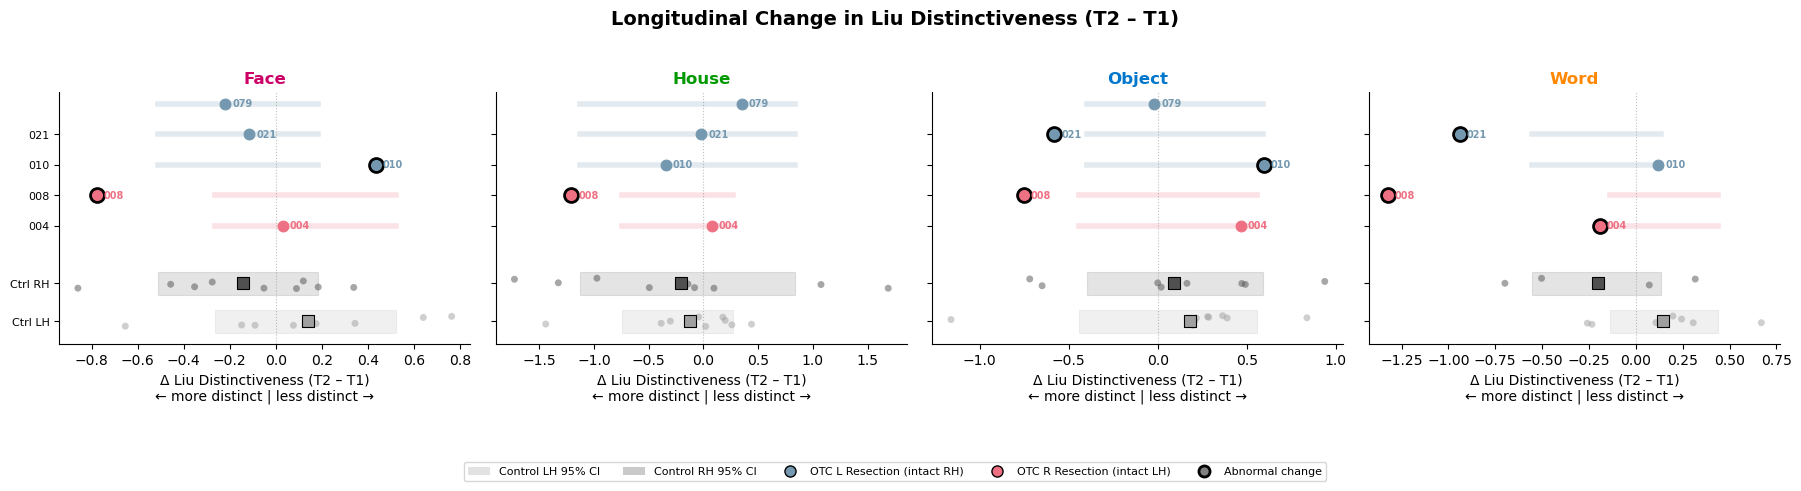

In [13]:
# CELL 9: Figure — Longitudinal Change in Liu Distinctiveness
# ═══════════════════════════════════════════════════════════════════════════════
# Change score dot plot: controls L/R as reference, OTC patients individually.
# Same layout as selectivity longitudinal figure.
# ═══════════════════════════════════════════════════════════════════════════════

if len(df_longitudinal) > 0:
    fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(4.5 * len(CATEGORIES), 4.5),
                              sharey=True)

    for col_idx, cat in enumerate(CATEGORIES):
        ax = axes[col_idx]

        for hemi_label, color, y_base in [('left', CTRL_L, 0), ('right', CTRL_R, 1)]:
            key = f'{cat}_{hemi_label}'
            if key not in ctrl_change:
                continue

            changes = ctrl_change[key]
            ci_lo = np.percentile(boot_change[key], 2.5)
            ci_hi = np.percentile(boot_change[key], 97.5)

            ax.barh(y_base, ci_hi - ci_lo, left=ci_lo, height=0.6,
                    color=color, alpha=0.15, edgecolor=color, linewidth=0.8)
            jit = RNG.uniform(-0.15, 0.15, len(changes))
            ax.scatter(changes, np.full(len(changes), y_base) + jit,
                       color=color, alpha=0.5, s=25, zorder=3, edgecolors='none')
            ax.scatter(changes.mean(), y_base, color=color, s=80, marker='s',
                       edgecolors='black', linewidth=0.8, zorder=5)

        pt_cat = df_longitudinal[df_longitudinal['category'] == cat]
        for i, (_, r) in enumerate(pt_cat.iterrows()):
            y_pos = 2.5 + i * 0.8
            side = 'left' if r['intact_hemi'] == 'right' else 'right'
            pt_color = OTC_L if side == 'left' else OTC_R

            marker_size = 100 if r['abnormal'] else 60
            edge = 'black' if r['abnormal'] else pt_color
            edge_w = 2.0 if r['abnormal'] else 0.8

            ax.scatter(r['change'], y_pos, color=pt_color, s=marker_size,
                       edgecolors=edge, linewidth=edge_w, zorder=5)
            ax.annotate(short_name(r['subject']),
                        (r['change'], y_pos), fontsize=7, fontweight='bold',
                        xytext=(5, 0), textcoords='offset points',
                        va='center', color=pt_color, zorder=6)

            boot_key = f'{cat}_{r["intact_hemi"]}'
            if boot_key in boot_change:
                bci_lo = np.percentile(boot_change[boot_key], 2.5)
                bci_hi = np.percentile(boot_change[boot_key], 97.5)
                ax.plot([bci_lo, bci_hi], [y_pos, y_pos],
                        color=pt_color, alpha=0.2, linewidth=4, zorder=1)

        ax.axvline(0, color='gray', linewidth=0.8, linestyle=':', alpha=0.5)
        ax.set_title(cat.title(), fontsize=12, fontweight='bold', color=CAT_COLORS[cat])
        if col_idx == 0:
            ax.set_ylabel('')
        ax.set_xlabel('Δ Liu Distinctiveness (T2 – T1)\n← more distinct | less distinct →')

        yticks = [0, 1] + [2.5 + i * 0.8 for i in range(len(pt_cat))]
        ylabels = ['Ctrl LH', 'Ctrl RH'] + [short_name(r['subject']) for _, r in pt_cat.iterrows()]
        ax.set_yticks(yticks)
        ax.set_yticklabels(ylabels, fontsize=8)

    legend_elements = [
        Patch(facecolor=CTRL_L, alpha=0.3, label='Control LH 95% CI'),
        Patch(facecolor=CTRL_R, alpha=0.3, label='Control RH 95% CI'),
        Line2D([0], [0], marker='o', color='none', markerfacecolor=OTC_L,
               markersize=8, label='OTC L Resection (intact RH)'),
        Line2D([0], [0], marker='o', color='none', markerfacecolor=OTC_R,
               markersize=8, label='OTC R Resection (intact LH)'),
        Line2D([0], [0], marker='o', color='none', markerfacecolor='gray',
               markeredgecolor='black', markeredgewidth=2, markersize=8,
               label='Abnormal change'),
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=5, fontsize=8, frameon=True, bbox_to_anchor=(0.5, -0.08))

    plt.suptitle('Longitudinal Change in Liu Distinctiveness (T2 – T1)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.07, 1, 0.95])
    plt.savefig(str(FIG_DIR / f'fig_longitudinal_change_liu_{COPE_SET}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('No longitudinal data available for plotting.')

In [14]:
# CELL 10: Longitudinal Summary Table
# ═══════════════════════════════════════════════════════════════════════════════

if len(df_longitudinal) > 0:
    print('='*70)
    print('LONGITUDINAL LIU DISTINCTIVENESS: Patient change vs control 95% CI')
    print('Abnormal = outside bootstrapped 95% CI of control change distribution')
    print('Positive Δ = becoming less distinct (degradation)')
    print('='*70)

    for _, r in df_longitudinal.sort_values(['sub', 'category']).iterrows():
        flag = '**' if r['abnormal'] else '  '
        direction = '↑' if r['change'] > 0 else '↓'
        print(f'{flag} {r["subject"]:<12} {r["category"]:<8} [{r["test_type"]:<6}]: '
              f'Δ={r["change"]:>+8.3f}  CI=[{r["ci_lo"]:>+8.3f}, {r["ci_hi"]:>+8.3f}] {direction}')

LONGITUDINAL LIU DISTINCTIVENESS: Patient change vs control 95% CI
Abnormal = outside bootstrapped 95% CI of control change distribution
Positive Δ = becoming less distinct (degradation)
   OTC004       face     [reorg ]: Δ=  +0.031  CI=[  -0.264,   +0.523] ↑
   OTC004       house    [reorg ]: Δ=  +0.078  CI=[  -0.742,   +0.269] ↑
   OTC004       object   [normal]: Δ=  +0.465  CI=[  -0.441,   +0.559] ↑
** OTC004       word     [normal]: Δ=  -0.193  CI=[  -0.138,   +0.438] ↓
** OTC008       face     [reorg ]: Δ=  -0.776  CI=[  -0.264,   +0.523] ↓
** OTC008       house    [reorg ]: Δ=  -1.208  CI=[  -0.742,   +0.269] ↓
** OTC008       object   [normal]: Δ=  -0.752  CI=[  -0.441,   +0.559] ↓
** OTC008       word     [normal]: Δ=  -1.325  CI=[  -0.138,   +0.438] ↓
** OTC010       face     [normal]: Δ=  +0.434  CI=[  -0.511,   +0.183] ↑
   OTC010       house    [normal]: Δ=  -0.343  CI=[  -1.129,   +0.832] ↓
** OTC010       object   [reorg ]: Δ=  +0.593  CI=[  -0.399,   +0.591] ↑
   OTC010 

In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 11: Pairwise Longitudinal Dissimilarity (Liu Replication + Extension)
# ═══════════════════════════════════════════════════════════════════════════════
#
# This directly follows Liu et al. (2025):
#   - Within each ROI sphere, track specific pairwise similarities T1 → T2
#   - Liu found: face-word similarity INCREASES over time (crowding)
#   - Liu assumed: house-object similarity is STABLE
#   - Our extension: test whether house-object is actually stable
#
# Key distinction from the Liu distinctiveness measure above:
#   - Liu distinctiveness averaged across all non-preferred pairs, one timepoint
#   - This tracks SPECIFIC pairs across TWO timepoints
#
# Positive change = categories becoming MORE similar within that ROI
#   face-word increasing in face ROI = face voxels becoming more word-like
# ═══════════════════════════════════════════════════════════════════════════════

pair_file = LIU_DIR / f'pairwise_correlations_{COPE_SET}.csv'
if not pair_file.exists():
    raise FileNotFoundError(f'{pair_file}')

df_pair = pd.read_csv(pair_file)

# Filter to canonical 4 ROI categories
df_pair = df_pair[df_pair['category'].isin(CATEGORIES)]
df_pair = df_pair[~df_pair['subject_id'].isin(EXCLUDE)]
df_pair = df_pair[~df_pair['subject'].astype(str).str.contains('017')]

# All 6 pairwise combinations
ALL_PAIRS = sorted(df_pair['pair'].unique())

# Key pairs per ROI (what Liu tracked)
KEY_PAIRS = {
    'face':   'face-word',      # competitive displacement
    'word':   'face-word',      # competitive displacement (other side)
    'house':  'house-object',   # Liu assumed stable
    'object': 'house-object',   # Liu assumed stable
}

# Identify longitudinal subjects
ses_counts = df_pair.groupby('subject_id')['session'].nunique()
multi_subs = ses_counts[ses_counts >= 2].index.tolist()
df_pair_long = df_pair[df_pair['subject_id'].isin(multi_subs)].copy()

# Rank sessions, keep first two
df_pair_long['ses_rank'] = df_pair_long.groupby('subject_id')['session'].rank(
    method='dense').astype(int)
df_pair_long = df_pair_long[df_pair_long['ses_rank'] <= 2]
df_pair_long['timepoint'] = df_pair_long['ses_rank'].map({1: 'T1', 2: 'T2'})

ctrl_pair = df_pair_long[df_pair_long['status'] == 'control'].copy()
otc_pair  = df_pair_long[(df_pair_long['group'] == 'OTC') &
                          (df_pair_long['hemi_label'] == 'intact')].copy()
otc_pair['intact_hemi'] = otc_pair['surgery_side'].map(
    lambda s: 'right' if s == 'left' else 'left')

print(f'Pairwise data loaded: {len(df_pair)} rows')
print(f'Pairs: {ALL_PAIRS}')
print(f'Longitudinal controls: {ctrl_pair["subject_id"].nunique()}')
print(f'Longitudinal OTC:      {otc_pair["subject_id"].nunique()}')


Pairwise data loaded: 2280 rows
Pairs: ['face-house', 'face-object', 'face-word', 'house-object', 'house-word', 'object-word']
Longitudinal controls: 9
Longitudinal OTC:      5


In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 12: Compute Pairwise T1→T2 Change Scores
# ═══════════════════════════════════════════════════════════════════════════════
# For each subject × ROI × pair: change = T2 fisher_r - T1 fisher_r
#
# Positive change = pair becoming MORE similar over time
#   In face ROI: face-word increasing = crowding (Liu's finding)
#   In house ROI: house-object increasing = categories blurring
# ═══════════════════════════════════════════════════════════════════════════════

def compute_pairwise_change(df):
    """Compute T1→T2 change for each subject × ROI category × pair."""
    rows = []
    for sub in sorted(df['subject_id'].unique()):
        sub_df = df[df['subject_id'] == sub]
        sub_code = sub_df['subject'].iloc[0]

        for roi_cat in CATEGORIES:
            for pair in ALL_PAIRS:
                t1 = sub_df[(sub_df['category'] == roi_cat) &
                            (sub_df['pair'] == pair) &
                            (sub_df['timepoint'] == 'T1')]['fisher_r']
                t2 = sub_df[(sub_df['category'] == roi_cat) &
                            (sub_df['pair'] == pair) &
                            (sub_df['timepoint'] == 'T2')]['fisher_r']

                if len(t1) == 0 or len(t2) == 0:
                    continue

                change = t2.values[0] - t1.values[0]
                is_key = (pair == KEY_PAIRS.get(roi_cat, ''))

                rows.append({
                    'subject_id': sub,
                    'subject': sub_code,
                    'group': sub_df['group'].iloc[0],
                    'status': sub_df['status'].iloc[0],
                    'surgery_side': sub_df['surgery_side'].iloc[0],
                    'hemi_label': sub_df['hemi_label'].iloc[0],
                    'roi_category': roi_cat,
                    'pair': pair,
                    'is_key_pair': is_key,
                    't1': t1.values[0],
                    't2': t2.values[0],
                    'change': change,
                })
    return pd.DataFrame(rows)

ctrl_change_pw = compute_pairwise_change(ctrl_pair)
otc_change_pw  = compute_pairwise_change(otc_pair)

print(f'Control change scores: {len(ctrl_change_pw)} rows')
print(f'OTC change scores:     {len(otc_change_pw)} rows')


Control change scores: 210 rows
OTC change scores:     114 rows


In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 13: Key Pair Analysis — face-word and house-object change by ROI
# ═══════════════════════════════════════════════════════════════════════════════
#
# Liu's core test: within face/word ROIs, does face-word similarity increase?
# Our extension: within house/object ROIs, does house-object similarity change?
#
# For each ROI × its key pair:
#   - Controls: paired t-test T1 vs T2, bootstrap change distribution
#   - OTC: individual patient change vs bootstrapped control change
# ═══════════════════════════════════════════════════════════════════════════════

N_BOOT_PW = 10000
rng_pw = np.random.default_rng(42)

print('='*70)
print('KEY PAIR ANALYSIS: T1→T2 change within each ROI')
print('  Positive change = categories becoming MORE similar (crowding)')
print('='*70)

boot_pw_change = {}  # for patient comparisons

for roi_cat in CATEGORIES:
    key_pair = KEY_PAIRS[roi_cat]
    print(f'\n{"─"*70}')
    print(f'ROI: {roi_cat} | Key pair: {key_pair}')
    print(f'{"─"*70}')

    # ── Controls ──────────────────────────────────────────────────────────
    ctrl_key = ctrl_change_pw[(ctrl_change_pw['roi_category'] == roi_cat) &
                               (ctrl_change_pw['pair'] == key_pair)]

    # Average across hemispheres per control subject first
    ctrl_by_sub = ctrl_key.groupby('subject_id')['change'].mean().values

    if len(ctrl_by_sub) >= 3:
        t_stat, t_p = sp_stats.ttest_1samp(ctrl_by_sub, 0)
        d = ctrl_by_sub.mean() / ctrl_by_sub.std() if ctrl_by_sub.std() > 0 else np.nan
        print(f'  Controls: n={len(ctrl_by_sub)}, '
              f'M change={ctrl_by_sub.mean():+.3f} (SD={ctrl_by_sub.std():.3f})')
        print(f'    t({len(ctrl_by_sub)-1})={t_stat:.3f}, p={t_p:.4f}, d={d:.3f}')
        direction = 'more similar' if ctrl_by_sub.mean() > 0 else 'less similar'
        print(f'    → Becoming {direction} over time')
    else:
        print(f'  Controls: n={len(ctrl_by_sub)} — too few')

    # ── Bootstrap control change distribution (per hemisphere) ────────────
    for hemi_label in ['left', 'right']:
        ctrl_hemi = ctrl_key[ctrl_key['hemi_label'] == hemi_label]['change'].values
        bk = f'{roi_cat}_{key_pair}_{hemi_label}'
        if len(ctrl_hemi) >= N_SUBS_BOOT:
            boot_means = np.empty(N_BOOT_PW)
            for i in range(N_BOOT_PW):
                idx = rng_pw.choice(len(ctrl_hemi), size=N_SUBS_BOOT, replace=False)
                boot_means[i] = ctrl_hemi[idx].mean()
            boot_pw_change[bk] = boot_means
            ci_lo = np.percentile(boot_means, 2.5)
            ci_hi = np.percentile(boot_means, 97.5)
            print(f'  Bootstrap {hemi_label}: n={len(ctrl_hemi)}, '
                  f'CI=[{ci_lo:+.3f}, {ci_hi:+.3f}]')

    # ── OTC patients ──────────────────────────────────────────────────────
    otc_key = otc_change_pw[(otc_change_pw['roi_category'] == roi_cat) &
                             (otc_change_pw['pair'] == key_pair)]

    if len(otc_key) == 0:
        print(f'  OTC: no data')
        continue

    print(f'\n  OTC patients:')
    for _, r in otc_key.iterrows():
        intact = r.get('hemi_label', 'intact')
        # Find matching bootstrap
        # Patient intact hemi → compare against same control hemi
        intact_hemi = 'left' if r['surgery_side'] == 'right' else 'right'
        bk = f'{roi_cat}_{key_pair}_{intact_hemi}'

        flag = ''
        if bk in boot_pw_change:
            bd = boot_pw_change[bk]
            pctile = float(np.mean(bd <= r['change']) * 100)
            ci_lo = np.percentile(bd, 2.5)
            ci_hi = np.percentile(bd, 97.5)
            if r['change'] > ci_hi:
                flag = '↑↑ ABNORMAL INCREASE (more similar)'
            elif r['change'] < ci_lo:
                flag = '↓↓ ABNORMAL DECREASE (less similar)'
            else:
                flag = f'within CI'
            flag += f' [{pctile:.0f}%]'
        else:
            flag = 'no bootstrap available'

        print(f'    {short_name(r["subject"])}: '
              f'T1={r["t1"]:+.3f}, T2={r["t2"]:+.3f}, '
              f'Δ={r["change"]:+.3f} → {flag}')


KEY PAIR ANALYSIS: T1→T2 change within each ROI
  Positive change = categories becoming MORE similar (crowding)

──────────────────────────────────────────────────────────────────────
ROI: face | Key pair: face-word
──────────────────────────────────────────────────────────────────────
  Controls: n=9, M change=+0.075 (SD=0.587)
    t(8)=0.361, p=0.7278, d=0.127
    → Becoming more similar over time
  Bootstrap left: n=9, CI=[-0.359, +0.497]

  OTC patients:
    004: T1=+0.105, T2=+0.271, Δ=+0.166 → within CI [61%]
    008: T1=+0.222, T2=+0.532, Δ=+0.310 → within CI [81%]
    010: T1=+0.780, T2=+1.474, Δ=+0.693 → no bootstrap available
    021: T1=+1.275, T2=+1.162, Δ=-0.112 → no bootstrap available
    079: T1=+0.950, T2=+0.609, Δ=-0.341 → no bootstrap available

──────────────────────────────────────────────────────────────────────
ROI: house | Key pair: house-object
──────────────────────────────────────────────────────────────────────
  Controls: n=9, M change=-0.102 (SD=0.630)
   

In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 14: All Pairs Summary — T1→T2 change within each ROI
# ═══════════════════════════════════════════════════════════════════════════════
# Full table: for each ROI × pair, mean change in controls and OTC.
# This lets us see the complete picture of what's changing where.
# ═══════════════════════════════════════════════════════════════════════════════

print('='*70)
print('ALL PAIRS: Mean T1→T2 change by ROI and pair')
print('  Positive = becoming more similar; Negative = becoming less similar')
print('='*70)

for roi_cat in CATEGORIES:
    print(f'\n  ROI: {roi_cat}')
    print(f'  {"pair":<16} {"ctrl M":>8} {"ctrl SD":>8} {"ctrl n":>6} '
          f'{"OTC M":>8} {"OTC SD":>8} {"OTC n":>6} {"key":>4}')
    print(f'  {"─"*72}')

    for pair in ALL_PAIRS:
        # Controls: average across hemispheres per subject
        ctrl_p = ctrl_change_pw[(ctrl_change_pw['roi_category'] == roi_cat) &
                                 (ctrl_change_pw['pair'] == pair)]
        ctrl_sub = ctrl_p.groupby('subject_id')['change'].mean()

        otc_p = otc_change_pw[(otc_change_pw['roi_category'] == roi_cat) &
                               (otc_change_pw['pair'] == pair)]

        is_key = '←' if pair == KEY_PAIRS.get(roi_cat, '') else ''

        cm = ctrl_sub.mean() if len(ctrl_sub) > 0 else np.nan
        cs = ctrl_sub.std() if len(ctrl_sub) > 1 else np.nan
        cn = len(ctrl_sub)
        om = otc_p['change'].mean() if len(otc_p) > 0 else np.nan
        os_ = otc_p['change'].std() if len(otc_p) > 1 else np.nan
        on = len(otc_p)

        print(f'  {pair:<16} {cm:>+8.3f} {cs:>8.3f} {cn:>6} '
              f'{om:>+8.3f} {os_:>8.3f} {on:>6} {is_key:>4}')

# ── Key pair summary ──────────────────────────────────────────────────────
print('\n' + '='*70)
print('SUMMARY: Key pairs only')
print('='*70)
print(f'{"ROI":<10} {"pair":<16} {"ctrl Δ":>8} {"OTC Δ":>8} {"direction":>20}')
print('─'*65)
for roi_cat in CATEGORIES:
    key_pair = KEY_PAIRS[roi_cat]
    ctrl_p = ctrl_change_pw[(ctrl_change_pw['roi_category'] == roi_cat) &
                             (ctrl_change_pw['pair'] == key_pair)]
    ctrl_m = ctrl_p.groupby('subject_id')['change'].mean().mean()

    otc_p = otc_change_pw[(otc_change_pw['roi_category'] == roi_cat) &
                           (otc_change_pw['pair'] == key_pair)]
    otc_m = otc_p['change'].mean() if len(otc_p) > 0 else np.nan

    direction = ''
    if np.isfinite(otc_m):
        if otc_m > 0:
            direction = 'more similar (crowd)'
        else:
            direction = 'less similar'

    print(f'{roi_cat:<10} {key_pair:<16} {ctrl_m:>+8.3f} {otc_m:>+8.3f} {direction:>20}')


ALL PAIRS: Mean T1→T2 change by ROI and pair
  Positive = becoming more similar; Negative = becoming less similar

  ROI: face
  pair               ctrl M  ctrl SD ctrl n    OTC M   OTC SD  OTC n  key
  ────────────────────────────────────────────────────────────────────────
  face-house         +0.183    0.490      9   -0.236    0.752      5     
  face-object        +0.156    0.447      9   -0.294    0.503      5     
  face-word          +0.075    0.623      9   +0.143    0.397      5    ←
  house-object       +0.096    0.546      9   -0.268    0.791      5     
  house-word         -0.095    0.554      9   +0.130    0.432      5     
  object-word        -0.125    0.348      9   +0.269    0.175      5     

  ROI: house
  pair               ctrl M  ctrl SD ctrl n    OTC M   OTC SD  OTC n  key
  ────────────────────────────────────────────────────────────────────────
  face-house         -0.191    0.621      9   -0.548    0.860      5     
  face-object        +0.326    0.492      9

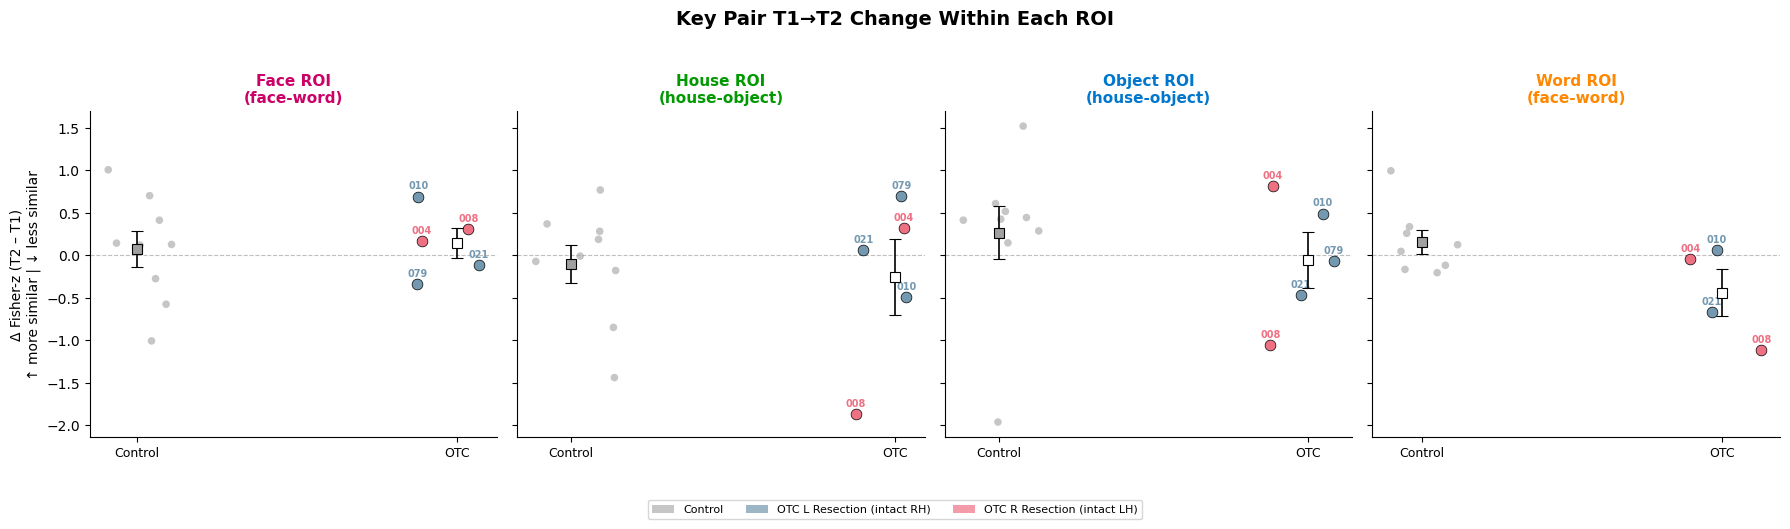

Saved: fig_pairwise_change_differential.png


In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 15: Figure — Key Pair Changes by ROI
# ═══════════════════════════════════════════════════════════════════════════════
# One panel per ROI, showing T1→T2 change in the key pair.
# Control distribution + individual OTC patients.
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(4.5 * len(CATEGORIES), 5),
                          sharey=True)

for col_idx, roi_cat in enumerate(CATEGORIES):
    ax = axes[col_idx]
    key_pair = KEY_PAIRS[roi_cat]

    # Control change scores (average across hemispheres per subject)
    ctrl_p = ctrl_change_pw[(ctrl_change_pw['roi_category'] == roi_cat) &
                             (ctrl_change_pw['pair'] == key_pair)]
    ctrl_sub_change = ctrl_p.groupby('subject_id')['change'].mean()

    # Plot controls
    if len(ctrl_sub_change) > 0:
        jit = RNG.uniform(-0.15, 0.15, len(ctrl_sub_change))
        ax.scatter(np.zeros(len(ctrl_sub_change)) + jit, ctrl_sub_change.values,
                   color=CTRL_L, alpha=0.6, s=30, zorder=3, edgecolors='none')
        ax.errorbar(0, ctrl_sub_change.mean(),
                    yerr=ctrl_sub_change.std() / np.sqrt(len(ctrl_sub_change)),
                    color='black', marker='s', markersize=7,
                    markerfacecolor=CTRL_L, markeredgecolor='black',
                    markeredgewidth=0.8, capsize=4, linewidth=1.2, zorder=5)

    # Plot OTC patients
    otc_p = otc_change_pw[(otc_change_pw['roi_category'] == roi_cat) &
                           (otc_change_pw['pair'] == key_pair)]
    for i, (_, r) in enumerate(otc_p.iterrows()):
        side = r.get('surgery_side', '')
        color = OTC_L if side == 'left' else OTC_R
        jit = RNG.uniform(-0.15, 0.15)
        ax.scatter(1 + jit, r['change'], color=color, s=60, zorder=4,
                   edgecolors='black', linewidth=0.5)
        ax.annotate(short_name(r['subject']),
                    (1 + jit, r['change']), fontsize=7, fontweight='bold',
                    ha='center', va='bottom', xytext=(0, 4),
                    textcoords='offset points', color=color)

    if len(otc_p) > 0:
        ax.errorbar(1, otc_p['change'].mean(),
                    yerr=otc_p['change'].std() / np.sqrt(max(len(otc_p), 1)),
                    color='black', marker='s', markersize=7,
                    markerfacecolor='white', markeredgecolor='black',
                    markeredgewidth=0.8, capsize=4, linewidth=1.2, zorder=5)

    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Control', 'OTC'], fontsize=9)
    ax.set_title(f'{roi_cat.title()} ROI\n({key_pair})',
                 fontsize=11, fontweight='bold', color=CAT_COLORS[roi_cat])
    if col_idx == 0:
        ax.set_ylabel('Δ Fisher-z (T2 – T1)\n↑ more similar | ↓ less similar')

legend_elements = [
    Patch(facecolor=CTRL_L, alpha=0.6, label='Control'),
    Patch(facecolor=OTC_L, alpha=0.7, label='OTC L Resection (intact RH)'),
    Patch(facecolor=OTC_R, alpha=0.7, label='OTC R Resection (intact LH)'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=3, fontsize=8, frameon=True, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Key Pair T1→T2 Change Within Each ROI', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(str(FIG_DIR / f'fig_pairwise_change_{COPE_SET}.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: fig_pairwise_change_{COPE_SET}.png')


In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# SUPPLEMENTAL: Crawford-Howell Single-Case Tests
# ═══════════════════════════════════════════════════════════════════════════════
# Included for PI review. Not part of main Ayzenberg-style analysis.
# Crawford & Howell (1998) modified t-test per patient × category,
# with BH-FDR correction.
# ═══════════════════════════════════════════════════════════════════════════════

def crawford_t(patient_val, ctrl_vals):
    """Crawford & Howell (1998) modified t-test: single case vs controls.
    Returns (t_stat, p_val, n_controls)."""
    ctrl_vals = np.asarray(ctrl_vals)
    ctrl_vals = ctrl_vals[np.isfinite(ctrl_vals)]
    n = len(ctrl_vals)
    if n < 3:
        return np.nan, np.nan, n
    m, s = ctrl_vals.mean(), ctrl_vals.std(ddof=1)
    if s == 0:
        return np.nan, np.nan, n
    t = (patient_val - m) / (s * np.sqrt((n + 1) / n))
    p = 2 * sp_stats.t.sf(abs(t), df=n - 1)
    return t, p, n


def bh_fdr(pvals, alpha=0.05):
    """Benjamini-Hochberg FDR correction. Returns boolean rejected array."""
    pvals = np.asarray(pvals, dtype=float)
    n     = len(pvals)
    if n == 0:
        return np.array([], dtype=bool)
    order    = np.argsort(pvals)
    ranked   = np.empty(n)
    ranked[order] = np.arange(1, n + 1)
    threshold = (ranked / n) * alpha
    below = pvals <= threshold
    if not below.any():
        return np.zeros(n, dtype=bool)
    cutoff = pvals[order[np.where(below)[0].max()]]
    return pvals <= cutoff


print('='*70)
print('SUPPLEMENTAL: Crawford-Howell single-case tests (Liu distinctiveness)')
print('='*70)

craw_rows = []
for grp_label, grp_df in [('OTC', otc), ('nonOTC', nonotc)]:
    for cat in CATEGORIES:
        ref = PREFERRED_CTRL_HEMI[cat]
        ctrl_vals = ctrl[(ctrl['category'] == cat) &
                         (ctrl['hemi_label'] == ref)][METRIC].values
        for _, row in grp_df[grp_df['category'] == cat].iterrows():
            t, p, n = crawford_t(row[METRIC], ctrl_vals)
            craw_rows.append({
                'subject': row['subject'], 'group': grp_label,
                'surgery_side': row['surgery_side'],
                'category': cat, 'value': row[METRIC],
                't': t, 'p': p,
            })

cdf = pd.DataFrame(craw_rows)
valid = cdf['p'].notna()
cdf['sig'] = False
if valid.sum() > 0:
    cdf.loc[valid, 'sig'] = bh_fdr(cdf.loc[valid, 'p'].values)

print(f'\n{"Subject":<12} {"Group":<8} {"Side":<8} {"Category":<10} '
      f'{"Value":>8} {"t":>8} {"p":>8} {"sig":>5}')
print('─' * 75)
for _, r in cdf.iterrows():
    sig = '*' if r['sig'] else ''
    print(f'{r["subject"]:<12} {r["group"]:<8} {r["surgery_side"]:<8} '
          f'{r["category"]:<10} {r["value"]:>8.3f} {r["t"]:>8.3f} '
          f'{r["p"]:>8.4f} {sig:>5}')

n_sig = cdf['sig'].sum()
print(f'\n  {n_sig}/{len(cdf)} significant after BH-FDR')

for cat in CATEGORIES:
    cat_df = cdf[cdf['category'] == cat]
    n_s = cat_df['sig'].sum()
    direction = 'higher (less distinct)' if cat_df['t'].mean() > 0 else 'lower (more distinct)'
    print(f'  {cat}: {n_s}/{len(cat_df)} sig, mean t={cat_df["t"].mean():.2f} '
          f'(OTC {direction} than controls)')

SUPPLEMENTAL: Crawford-Howell single-case tests (Liu distinctiveness)

Subject      Group    Side     Category      Value        t        p   sig
───────────────────────────────────────────────────────────────────────────
OTC004       OTC      right    face          0.424   -0.718   0.4810      
OTC008       OTC      right    face          1.108    0.999   0.3298      
OTC010       OTC      left     face          0.612   -0.246   0.8082      
OTC021       OTC      left     face          1.224    1.291   0.2115      
OTC066       OTC      left     face          0.859    0.375   0.7117      
OTC069       OTC      left     face          0.820    0.277   0.7846      
OTC075       OTC      right    face          1.002    0.733   0.4720      
OTC076       OTC      right    face          1.096    0.971   0.3434      
OTC077       OTC      right    face          0.793    0.208   0.8372      
OTC078       OTC      left     face          1.058    0.875   0.3922      
OTC079       OTC      left  

In [22]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL: Pairwise Searchmask Analysis (Liu Replication)
# ═══════════════════════════════════════════════════════════════════════════════
#
# Uses pairwise correlations from FULL SEARCHMASKS (not 6mm spheres).
# This captures boundary voxels where competitive displacement occurs.
#
# Key: face and word share the SAME searchmask (Temporal Fusiform),
# so face-word competition within the face/word searchmask directly
# replicates Liu's measurement.
#
# Data: pairwise_searchmask_{COPE_SET}.csv
#   (produced by 09_pairwise_searchmask.py)
# ═══════════════════════════════════════════════════════════════════════════════

sm_file = LIU_DIR / f'pairwise_searchmask_{COPE_SET}.csv'
if not sm_file.exists():
    print(f'SKIP: {sm_file} not found — run 09_pairwise_searchmask.py first')
else:
    df_sm = pd.read_csv(sm_file)
    df_sm = df_sm[df_sm['searchmask'].isin(CATEGORIES)]
    df_sm = df_sm[~df_sm['subject_id'].isin(EXCLUDE)]
    df_sm = df_sm[~df_sm['subject'].astype(str).str.contains('017')]

    ALL_PAIRS = sorted(df_sm['pair'].unique())
    KEY_PAIRS_SM = {
        'face':   'face-word',
        'word':   'face-word',
        'house':  'house-object',
        'object': 'house-object',
    }

    # ── Longitudinal subset ───────────────────────────────────────────────
    ses_counts = df_sm.groupby('subject_id')['session'].nunique()
    multi_subs = ses_counts[ses_counts >= 2].index.tolist()
    df_sm_long = df_sm[df_sm['subject_id'].isin(multi_subs)].copy()

    df_sm_long['ses_rank'] = df_sm_long.groupby('subject_id')['session'].rank(
        method='dense').astype(int)
    df_sm_long = df_sm_long[df_sm_long['ses_rank'] <= 2]
    df_sm_long['timepoint'] = df_sm_long['ses_rank'].map({1: 'T1', 2: 'T2'})

    ctrl_sm = df_sm_long[df_sm_long['status'] == 'control'].copy()
    otc_sm  = df_sm_long[(df_sm_long['group'] == 'OTC') &
                          (df_sm_long['hemi_label'] == 'intact')].copy()
    otc_sm['intact_hemi'] = otc_sm['surgery_side'].map(
        lambda s: 'right' if s == 'left' else 'left')

    print(f'Searchmask pairwise data loaded')
    print(f'  Longitudinal controls: {ctrl_sm["subject_id"].nunique()}')
    print(f'  Longitudinal OTC:      {otc_sm["subject_id"].nunique()}')

    # ── Compute T1→T2 change scores ──────────────────────────────────────
    def compute_sm_change(df):
        rows = []
        for sub in sorted(df['subject_id'].unique()):
            sub_df = df[df['subject_id'] == sub]
            sub_code = sub_df['subject'].iloc[0]
            for sm_cat in CATEGORIES:
                for pair in ALL_PAIRS:
                    t1 = sub_df[(sub_df['searchmask'] == sm_cat) &
                                (sub_df['pair'] == pair) &
                                (sub_df['timepoint'] == 'T1')]['fisher_r']
                    t2 = sub_df[(sub_df['searchmask'] == sm_cat) &
                                (sub_df['pair'] == pair) &
                                (sub_df['timepoint'] == 'T2')]['fisher_r']
                    if len(t1) == 0 or len(t2) == 0:
                        continue
                    rows.append({
                        'subject_id': sub, 'subject': sub_code,
                        'group': sub_df['group'].iloc[0],
                        'status': sub_df['status'].iloc[0],
                        'surgery_side': sub_df['surgery_side'].iloc[0],
                        'hemi_label': sub_df['hemi_label'].iloc[0],
                        'searchmask': sm_cat, 'pair': pair,
                        'is_key': pair == KEY_PAIRS_SM.get(sm_cat, ''),
                        't1': t1.values[0], 't2': t2.values[0],
                        'change': t2.values[0] - t1.values[0],
                    })
        return pd.DataFrame(rows)

    ctrl_sm_ch = compute_sm_change(ctrl_sm)
    otc_sm_ch  = compute_sm_change(otc_sm)

    # ── Key pair analysis ─────────────────────────────────────────────────
    print('\n' + '='*70)
    print('SEARCHMASK KEY PAIR ANALYSIS: T1→T2 change')
    print('  Positive = becoming MORE similar (crowding)')
    print('  face/word searchmasks share same territory (Temporal Fusiform)')
    print('='*70)

    N_BOOT_SM = 10000
    rng_sm = np.random.default_rng(42)
    boot_sm = {}

    for sm_cat in CATEGORIES:
        key_pair = KEY_PAIRS_SM[sm_cat]
        print(f'\n{"─"*70}')
        print(f'Searchmask: {sm_cat} | Key pair: {key_pair}')
        print(f'{"─"*70}')

        # Controls
        ctrl_k = ctrl_sm_ch[(ctrl_sm_ch['searchmask'] == sm_cat) &
                             (ctrl_sm_ch['pair'] == key_pair)]
        ctrl_by_sub = ctrl_k.groupby('subject_id')['change'].mean()

        if len(ctrl_by_sub) >= 3:
            t_stat, t_p = sp_stats.ttest_1samp(ctrl_by_sub.values, 0)
            d = ctrl_by_sub.mean() / ctrl_by_sub.std() if ctrl_by_sub.std() > 0 else np.nan
            direction = 'more similar' if ctrl_by_sub.mean() > 0 else 'less similar'
            print(f'  Controls: n={len(ctrl_by_sub)}, '
                  f'M={ctrl_by_sub.mean():+.3f} (SD={ctrl_by_sub.std():.3f})')
            print(f'    t({len(ctrl_by_sub)-1})={t_stat:.3f}, p={t_p:.4f}, d={d:.3f}')
            print(f'    → Becoming {direction} over time')

        # Bootstrap per hemisphere
        for hl in ['left', 'right']:
            ctrl_h = ctrl_k[ctrl_k['hemi_label'] == hl]['change'].values
            bk = f'{sm_cat}_{key_pair}_{hl}'
            if len(ctrl_h) >= N_SUBS_BOOT:
                bm = np.empty(N_BOOT_SM)
                for i in range(N_BOOT_SM):
                    idx = rng_sm.choice(len(ctrl_h), size=N_SUBS_BOOT, replace=False)
                    bm[i] = ctrl_h[idx].mean()
                boot_sm[bk] = bm
                ci_lo = np.percentile(bm, 2.5)
                ci_hi = np.percentile(bm, 97.5)
                print(f'  Bootstrap {hl}: n={len(ctrl_h)}, CI=[{ci_lo:+.3f}, {ci_hi:+.3f}]')

        # OTC patients
        otc_k = otc_sm_ch[(otc_sm_ch['searchmask'] == sm_cat) &
                           (otc_sm_ch['pair'] == key_pair)]
        if len(otc_k) > 0:
            print(f'\n  OTC patients:')
            for _, r in otc_k.iterrows():
                intact_hemi = 'left' if r['surgery_side'] == 'right' else 'right'
                bk = f'{sm_cat}_{key_pair}_{intact_hemi}'
                flag = ''
                if bk in boot_sm:
                    bd = boot_sm[bk]
                    pctile = float(np.mean(bd <= r['change']) * 100)
                    ci_lo = np.percentile(bd, 2.5)
                    ci_hi = np.percentile(bd, 97.5)
                    if r['change'] > ci_hi:
                        flag = f'↑↑ ABNORMAL (more similar) [{pctile:.0f}%]'
                    elif r['change'] < ci_lo:
                        flag = f'↓↓ ABNORMAL (less similar) [{pctile:.0f}%]'
                    else:
                        flag = f'within CI [{pctile:.0f}%]'
                else:
                    flag = 'no bootstrap'
                print(f'    {short_name(r["subject"])}: '
                      f'T1={r["t1"]:+.3f}, T2={r["t2"]:+.3f}, '
                      f'Δ={r["change"]:+.3f} → {flag}')

    # ── Full table ────────────────────────────────────────────────────────
    print('\n' + '='*70)
    print('ALL PAIRS (searchmask): Mean T1→T2 change')
    print('='*70)
    for sm_cat in CATEGORIES:
        print(f'\n  Searchmask: {sm_cat}')
        print(f'  {"pair":<16} {"ctrl M":>8} {"ctrl SD":>8} {"n":>4} '
              f'{"OTC M":>8} {"OTC SD":>8} {"n":>4} {"key":>4}')
        print(f'  {"─"*68}')
        for pair in ALL_PAIRS:
            ctrl_p = ctrl_sm_ch[(ctrl_sm_ch['searchmask'] == sm_cat) &
                                 (ctrl_sm_ch['pair'] == pair)]
            ctrl_sub = ctrl_p.groupby('subject_id')['change'].mean()
            otc_p = otc_sm_ch[(otc_sm_ch['searchmask'] == sm_cat) &
                               (otc_sm_ch['pair'] == pair)]
            is_key = '←' if pair == KEY_PAIRS_SM.get(sm_cat, '') else ''
            cm = ctrl_sub.mean() if len(ctrl_sub) > 0 else np.nan
            cs = ctrl_sub.std() if len(ctrl_sub) > 1 else np.nan
            cn = len(ctrl_sub)
            om = otc_p['change'].mean() if len(otc_p) > 0 else np.nan
            os_ = otc_p['change'].std() if len(otc_p) > 1 else np.nan
            on = len(otc_p)
            print(f'  {pair:<16} {cm:>+8.3f} {cs:>8.3f} {cn:>4} '
                  f'{om:>+8.3f} {os_:>8.3f} {on:>4} {is_key:>4}')

    # ── Summary ───────────────────────────────────────────────────────────
    print('\n' + '='*70)
    print('SUMMARY: Key pairs — Sphere vs Searchmask comparison')
    print('='*70)
    print(f'{"Searchmask":<12} {"pair":<16} {"ctrl Δ":>8} {"OTC Δ":>8} {"direction":>20}')
    print('─'*68)
    for sm_cat in CATEGORIES:
        kp = KEY_PAIRS_SM[sm_cat]
        ctrl_p = ctrl_sm_ch[(ctrl_sm_ch['searchmask'] == sm_cat) &
                             (ctrl_sm_ch['pair'] == kp)]
        ctrl_m = ctrl_p.groupby('subject_id')['change'].mean().mean()
        otc_p = otc_sm_ch[(otc_sm_ch['searchmask'] == sm_cat) &
                           (otc_sm_ch['pair'] == kp)]
        otc_m = otc_p['change'].mean() if len(otc_p) > 0 else np.nan
        direction = ''
        if np.isfinite(otc_m):
            direction = 'more similar (crowd)' if otc_m > 0 else 'less similar'
        print(f'{sm_cat:<12} {kp:<16} {ctrl_m:>+8.3f} {otc_m:>+8.3f} {direction:>20}')

Searchmask pairwise data loaded
  Longitudinal controls: 9
  Longitudinal OTC:      5

SEARCHMASK KEY PAIR ANALYSIS: T1→T2 change
  Positive = becoming MORE similar (crowding)
  face/word searchmasks share same territory (Temporal Fusiform)

──────────────────────────────────────────────────────────────────────
Searchmask: face | Key pair: face-word
──────────────────────────────────────────────────────────────────────
  Controls: n=9, M=+0.114 (SD=0.282)
    t(8)=1.211, p=0.2604, d=0.404
    → Becoming more similar over time
  Bootstrap left: n=9, CI=[-0.068, +0.313]

  OTC patients:
    004: T1=+0.422, T2=+0.557, Δ=+0.135 → within CI [58%]
    008: T1=+0.002, T2=+0.553, Δ=+0.552 → ↑↑ ABNORMAL (more similar) [100%]
    010: T1=+0.720, T2=+0.292, Δ=-0.428 → no bootstrap
    021: T1=+1.895, T2=+1.586, Δ=-0.309 → no bootstrap
    079: T1=+1.266, T2=+1.054, Δ=-0.212 → no bootstrap

──────────────────────────────────────────────────────────────────────
Searchmask: house | Key pair: house-o

In [23]:
# ═══════════════════════════════════════════════════════════════════════════════
# SENSITIVITY: Pairwise searchmask WITHOUT sub-008 (hemispherectomy)
# ═══════════════════════════════════════════════════════════════════════════════

print('='*70)
print('SENSITIVITY: Pairwise searchmask WITHOUT sub-008')
print('='*70)

otc_sm_no008 = otc_sm_ch[~otc_sm_ch['subject'].str.contains('008')]

KEY_PAIRS_SM = {
    'face':   'face-word',
    'word':   'face-word',
    'house':  'house-object',
    'object': 'house-object',
}

print(f'\n{"Searchmask":<12} {"pair":<16} {"ctrl Δ":>8} {"OTC all":>8} {"OTC no008":>10}')
print('─'*60)
for sm_cat in CATEGORIES:
    kp = KEY_PAIRS_SM[sm_cat]
    ctrl_p = ctrl_sm_ch[(ctrl_sm_ch['searchmask'] == sm_cat) &
                         (ctrl_sm_ch['pair'] == kp)]
    ctrl_m = ctrl_p.groupby('subject_id')['change'].mean().mean()

    otc_all = otc_sm_ch[(otc_sm_ch['searchmask'] == sm_cat) &
                         (otc_sm_ch['pair'] == kp)]
    otc_no  = otc_sm_no008[(otc_sm_no008['searchmask'] == sm_cat) &
                            (otc_sm_no008['pair'] == kp)]

    m_all = otc_all['change'].mean() if len(otc_all) > 0 else np.nan
    m_no  = otc_no['change'].mean() if len(otc_no) > 0 else np.nan

    print(f'{sm_cat:<12} {kp:<16} {ctrl_m:>+8.3f} {m_all:>+8.3f} {m_no:>+10.3f}')

# Face-word detail per patient (excluding 008)
print(f'\nFace-word change in face/word searchmask (no sub-008):')
fw = otc_sm_no008[(otc_sm_no008['searchmask'] == 'face') &
                   (otc_sm_no008['pair'] == 'face-word')]
for _, r in fw.iterrows():
    print(f'  {short_name(r["subject"])}: Δ={r["change"]:+.3f}')

# House-object detail per patient (excluding 008)
print(f'\nHouse-object change in house searchmask (no sub-008):')
ho = otc_sm_no008[(otc_sm_no008['searchmask'] == 'house') &
                   (otc_sm_no008['pair'] == 'house-object')]
for _, r in ho.iterrows():
    print(f'  {short_name(r["subject"])}: Δ={r["change"]:+.3f}')

SENSITIVITY: Pairwise searchmask WITHOUT sub-008

Searchmask   pair               ctrl Δ  OTC all  OTC no008
────────────────────────────────────────────────────────────
face         face-word          +0.114   -0.053     -0.204
house        house-object       +0.110   -0.407     -0.075
object       house-object       +0.061   +0.064     +0.049
word         face-word          +0.114   -0.053     -0.204

Face-word change in face/word searchmask (no sub-008):
  004: Δ=+0.135
  010: Δ=-0.428
  021: Δ=-0.309
  079: Δ=-0.212

House-object change in house searchmask (no sub-008):
  004: Δ=-0.221
  010: Δ=-0.415
  021: Δ=+0.401
  079: Δ=-0.065
